In [6]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers

import numpy as np
import matplotlib.pyplot as plt

In [7]:
from keras import backend as K
print(K.backend())

tensorflow


In [8]:
# Create the model
inputs = keras.Input(shape=(784,))
x = layers.Dense(256, activation="relu")(inputs)
outputs = layers.Dense(10, activation="softmax")(x)
model = keras.Model(inputs=inputs, outputs=outputs, name="mnist_model")

In [9]:
model.summary()

Model: "mnist_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 784)]             0         
                                                                 
 dense_2 (Dense)             (None, 256)               200960    
                                                                 
 dense_3 (Dense)             (None, 10)                2570      
                                                                 
Total params: 203,530
Trainable params: 203,530
Non-trainable params: 0
_________________________________________________________________


In [10]:
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.reshape(60000, 784).astype("float32") / 255
x_test = x_test.reshape(10000, 784).astype("float32") / 255

In [11]:
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

In [12]:
history = model.fit(x_train, y_train, batch_size=64, epochs=10, validation_split=0.2)

Epoch 1/10
 94/750 [==>...........................] - ETA: 0s - loss: 0.6837 - accuracy: 0.8110  

2025-03-21 11:53:10.763251: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


750/750 [==============================] - 1s 732us/step - loss: 0.2886 - accuracy: 0.9175 - val_loss: 0.1650 - val_accuracy: 0.9534
Epoch 2/10
750/750 [==============================] - 1s 743us/step - loss: 0.1206 - accuracy: 0.9649 - val_loss: 0.1126 - val_accuracy: 0.9653
Epoch 3/10
750/750 [==============================] - 1s 821us/step - loss: 0.0792 - accuracy: 0.9764 - val_loss: 0.0896 - val_accuracy: 0.9737
Epoch 4/10
750/750 [==============================] - 1s 763us/step - loss: 0.0586 - accuracy: 0.9828 - val_loss: 0.0861 - val_accuracy: 0.9742
Epoch 5/10
750/750 [==============================] - 1s 792us/step - loss: 0.0428 - accuracy: 0.9873 - val_loss: 0.0864 - val_accuracy: 0.9732
Epoch 6/10
750/750 [==============================] - 1s 736us/step - loss: 0.0336 - accuracy: 0.9906 - val_loss: 0.0848 - val_accuracy: 0.9726
Epoch 7/10
750/750 [==============================] - 1s 724us/step - loss: 0.0245 - accuracy: 0.9932 - val_loss: 0.0779 - val_accuracy: 0.9768
Epo

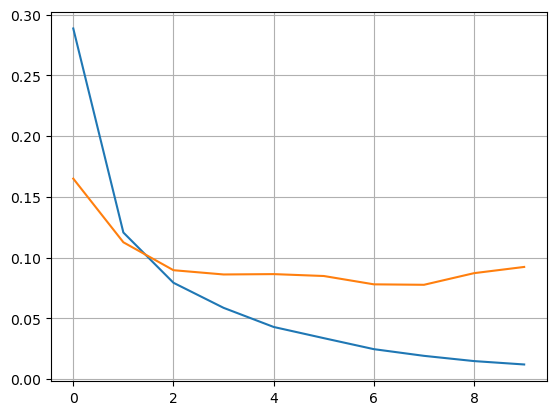

In [13]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.grid()
plt.show()

In [14]:
test_scores = model.evaluate(x_test, y_test, verbose=2)
print("Test loss:", test_scores[0])
print("Test accuracy:", test_scores[1])

313/313 - 0s - loss: 0.0788 - accuracy: 0.9787 - 98ms/epoch - 313us/step
Test loss: 0.07875500619411469
Test accuracy: 0.9786999821662903


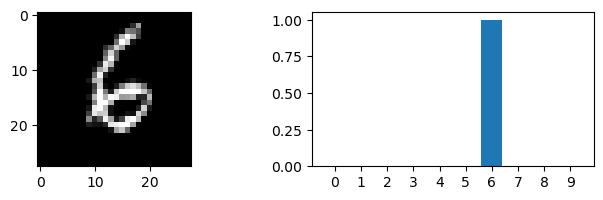

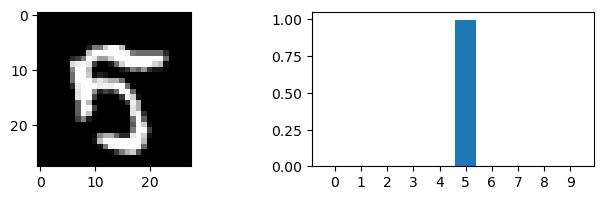

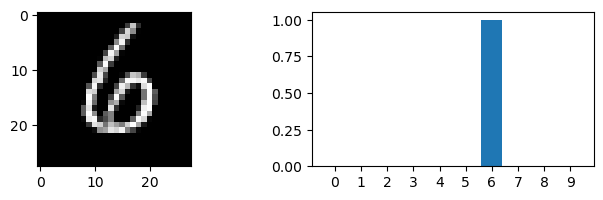

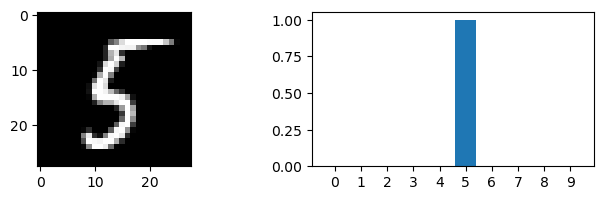

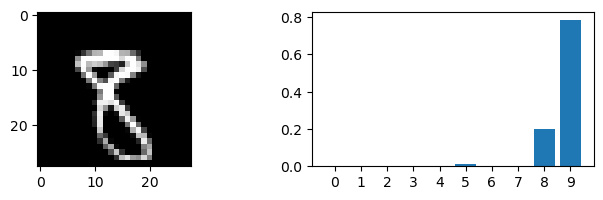

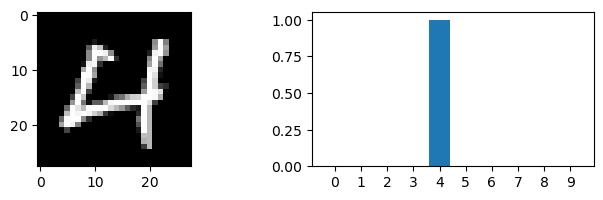

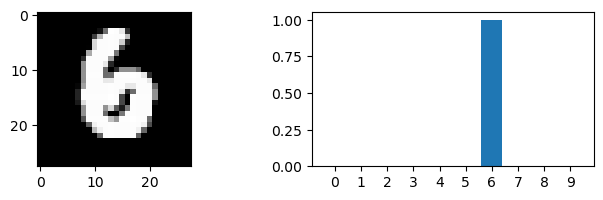

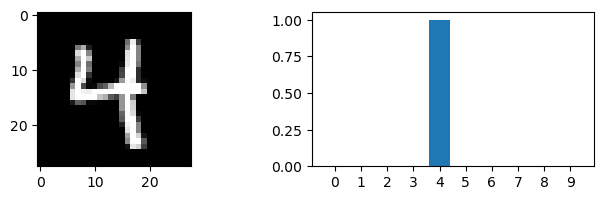

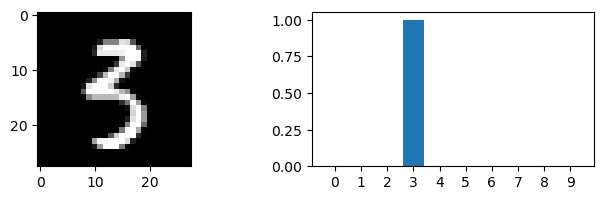

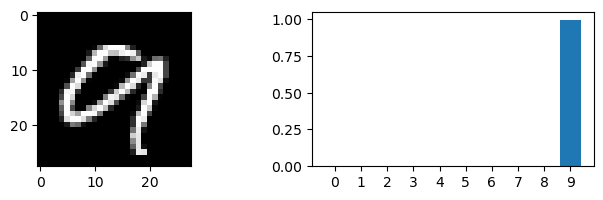

In [15]:
x = x_test
y = model(x)
start = 2000

for k in range(10):
    plt.figure(figsize=(8, 2))
    plt.subplot(1,2,1)
    plt.imshow(x[start+k].reshape((28, 28)), cmap='gray')
    ind = np.arange(0, 10)
    plt.subplot(1,2,2)
    plt.bar(ind, y[start+k].numpy().flatten())
    plt.xticks(range(10))